<a href="https://colab.research.google.com/github/IshaCodex/OIBSIP/blob/main/DataAnalytics-L1-CustomerSegmentation/Task2_CustomerSegmentatio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the dataset
df = pd.read_csv('/content/global_ecommerce_sales.csv')

# Inspect structure and check for nulls
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB
None

Missing values:
 Order_I

# Descriptive Statistics

Before clustering, we need a baseline understanding of our customers' purchasing behavior. We will calculate the average purchase value, purchase frequency, and a basic Customer Lifetime Value (CLV) proxy.

In [2]:
# Calculate basic behavioral stats
avg_purchase_value = df['Total_Sales'].mean()
purchase_frequency = df.groupby('Customer_Name')['Order_ID'].count().mean()
avg_clv = df.groupby('Customer_Name')['Total_Sales'].sum().mean()

print(f"Average Purchase Value: ${avg_purchase_value:.2f}")
print(f"Average Purchase Frequency (Orders per Customer): {purchase_frequency:.2f}")
print(f"Average Customer Lifetime Value (Total Spent): ${avg_clv:.2f}")

Average Purchase Value: $242.28
Average Purchase Frequency (Orders per Customer): 1.30
Average Customer Lifetime Value (Total Spent): $315.88


# Feature Selection (RFM Analysis)

We will extract three key behavioral features for clustering using the RFM model:

Recency: How many days since the customer's last purchase?

Frequency: How many total orders has the customer placed?

Monetary: What is the total amount the customer has spent?

In [3]:
# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Define a reference date (1 day after the latest purchase in the dataset)
reference_date = df['Order_Date'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics per customer
rfm = df.groupby('Customer_Name').agg({
    'Order_Date': lambda x: (reference_date - x.max()).days,
    'Order_ID': 'count',
    'Total_Sales': 'sum'
}).rename(columns={
    'Order_Date': 'Recency',
    'Order_ID': 'Frequency',
    'Total_Sales': 'Monetary'
})

display(rfm.head())

,Recency,Frequency,Monetary
Customer_Name,,,
Ahmed Ali,384,1,509.12
Ahmed Anderson,494,1,133.68
Ahmed Clark,636,2,94.28
Ahmed Dubois,23,3,105.73
Ahmed Garcia,923,2,1769.48


# Data Standardization

Because K-Means calculates distances between data points, features with larger scales (like Monetary) will unfairly dominate features with smaller scales (like Frequency). We will use StandardScaler to normalize the data.

In [4]:
# Initialize scaler
scaler = StandardScaler()

# Scale the RFM features
rfm_scaled = scaler.fit_transform(rfm)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm.columns, index=rfm.index)

display(rfm_scaled_df.head())

,Recency,Frequency,Monetary
Customer_Name,,,
Ahmed Ali,-0.312617,-0.536164,0.426506
Ahmed Anderson,0.037446,-0.536164,-0.402138
Ahmed Clark,0.489345,1.228804,-0.489099
Ahmed Dubois,-1.461459,2.993773,-0.463827
Ahmed Garcia,1.402691,1.228804,3.208282


## The Elbow Method

We will run the K-Means algorithm for multiple cluster sizes (K) and plot the inertia (Within-Cluster Sum of Squares) to determine the optimal number of segments for our customer base.

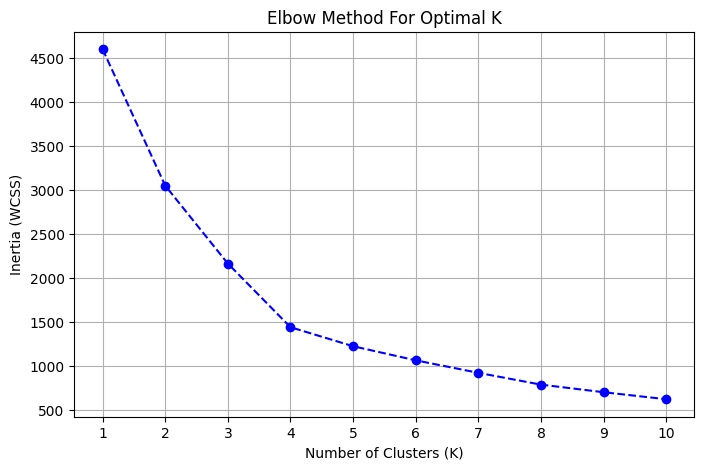

In [5]:
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Apply K-Means Clustering

Based on the elbow plot (which typically bends around K=3 or 4), we will segment our customers into 3 distinct clusters. We will add these cluster labels back to our unscaled RFM dataframe for analysis.

In [6]:
# Apply KMeans with 3 clusters
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

# Map numeric clusters to descriptive names for readability
cluster_names = {0: 'Segment 0', 1: 'Segment 1', 2: 'Segment 2'}
rfm['Cluster_Name'] = rfm['Cluster'].map(cluster_names)

display(rfm.head())

,Recency,Frequency,Monetary,Cluster,Cluster_Name
Customer_Name,,,,,
Ahmed Ali,384,1,509.12,0,Segment 0
Ahmed Anderson,494,1,133.68,0,Segment 0
Ahmed Clark,636,2,94.28,2,Segment 2
Ahmed Dubois,23,3,105.73,2,Segment 2
Ahmed Garcia,923,2,1769.48,2,Segment 2


# Visualizing the Clusters

We will create scatter plots to visualize how the clusters separate based on different combinations of our behavioral features.

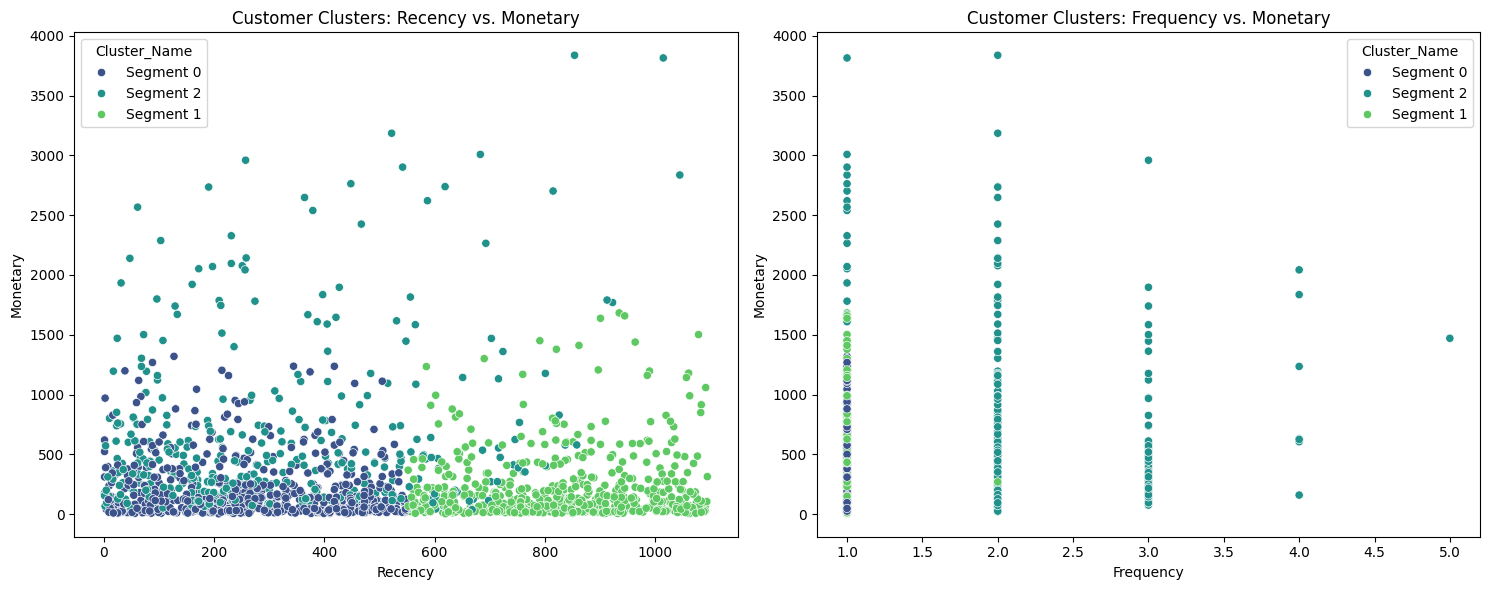

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Recency vs Monetary
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster_Name', data=rfm, palette='viridis', ax=axes[0])
axes[0].set_title('Customer Clusters: Recency vs. Monetary')

# Frequency vs Monetary
sns.scatterplot(x='Frequency', y='Monetary', hue='Cluster_Name', data=rfm, palette='viridis', ax=axes[1])
axes[1].set_title('Customer Clusters: Frequency vs. Monetary')

plt.tight_layout()
plt.show()

# Profiling the Clusters

We will calculate the average Recency, Frequency, and Monetary values for each cluster to understand the characteristics of that specific customer type.

In [8]:
# Calculate mean values for each cluster
cluster_profile = rfm.groupby('Cluster_Name').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
})

# Flatten column names for easier reading
cluster_profile.columns = ['Avg Recency (Days)', 'Avg Frequency', 'Avg Monetary ($)', 'Customer Count']
display(cluster_profile)

,Avg Recency (Days),Avg Frequency,Avg Monetary ($),Customer Count
Cluster_Name,,,,
Segment 0,269.404437,1.000000,197.085614,586
Segment 1,824.406417,1.044563,219.894439,561
Segment 2,308.483204,2.139535,634.900233,387


# Customer Distribution by Segment

Finally, we will visualize the total number of customers residing in each of our newly created segments.

/tmp/ipykernel_960/1065484363.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster_Name', data=rfm, palette='viridis')


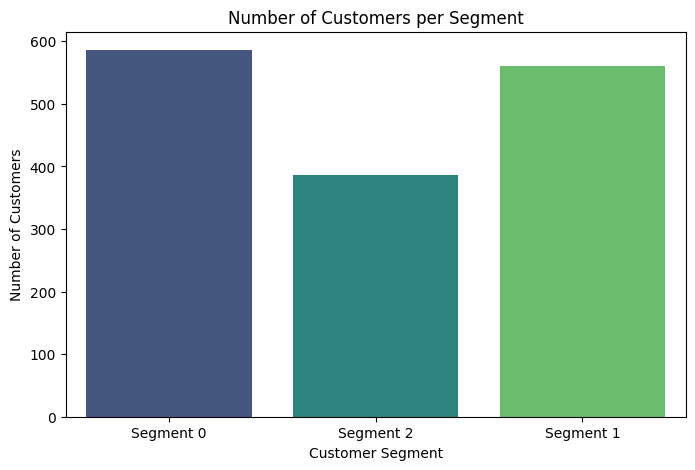

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Cluster_Name', data=rfm, palette='viridis')
plt.title('Number of Customers per Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.show()

# Business Insights & Recommendations

Based on the cluster profiling, here are the recommended marketing strategies for each segment:

1. High-Value / Loyal Customers (High Frequency, High Monetary, Low Recency): These are the most profitable shoppers. Recommend sending them VIP perks, early access to new collections, or a premium loyalty tier to retain their business.

2. At-Risk / Dormant Customers (High Recency, Low Frequency, Low Monetary): These customers haven't purchased in a long time. Recommend launching a re-engagement email campaign featuring a heavy "We Miss You" discount code to win them back.

3. New / Occasional Shoppers (Average Recency, Average Monetary): These shoppers show potential but haven't formed a habit yet. Recommend targeting them with product recommendations based on their first purchase or offering a free shipping threshold to increase their average order value.